In [1]:
pip install -e ..

Obtaining file:///home/sagar/winogender_contextuality
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for winogender_contextuality (pyproject.toml) ... done
  Created wheel for winogender_contextuality: filename=winogender_contextuality-0.0.1-py3-none-any.whl size=3680 sha256=7eaeda3a55298dce1ac4d00ae011d0f0629bc206b66dd3eb3821d0ed21b9bdb9
  Stored in directory: /tmp/pip-ephem-wheel-cache-e3cmnnlo/wheels/f6/b9/38/03ac5a5ccd63b90faa34c1614fd3e708a9c34ab8edb44270e9
Successfully built winogender_contextuality
  Attempting uninstall: winogender_contextuality
    Found existing installation: winogender_contextuality 0.0.1
    Uninstalling winogender_contextuality-0.0.1:
      Successfully uninstalled winogender_contextuality-0.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.config import * 

2025-09-19 16:57:13.707 | INFO     | winogender_contextuality.config:<module>:13 - PROJ_ROOT path is: /home/sagar/winogender_contextuality
2025-09-19 16:57:13.708 | INFO     | winogender_contextuality.config:<module>:17 - DATA_ROOT path is: /data_users1/sagar/winogender_contextuality


In [3]:
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict, Counter, OrderedDict
from tqdm.notebook import tqdm
import pandas as pd
from scipy import stats
from sklearn.metrics import log_loss, roc_auc_score
import statsmodels.formula.api as smf
import statsmodels.api as sm
from loguru import logger

# Data Loading

In [4]:
templates = pd.read_csv(RAW_DATA_DIR / "templates.tsv", sep='\t')

## Llama

In [5]:
# T = 0.5
llama32 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.503.ndjson")
max_llama = max([d['index'] for d in llama32])

In [6]:
# T = 0.7
llama32_07 =load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.703.ndjson")

In [7]:
# T = 0.3
llama32_03 =load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.303_1904100925.ndjson")

In [8]:
# Neutral Pronouns
llama32_neutral = load_ndjson(INTERIM_DATA_DIR/"one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1425050925.ndjson")

In [9]:
# Prompted to ignore order
llama_order_prompt = load_ndjson(INTERIM_DATA_DIR/"one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1558060925.ndjson")

## Qwen

In [10]:
qwen15 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen1.5-0.5B-Chat_0.501.ndjson")
max_qwen = max([d['index'] for d in qwen15])

## GPT

In [11]:
gpt = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5.ndjson")
max_gpt = max([d['index'] for d in gpt])

In [12]:
gpt_03 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.3.ndjson")

In [13]:
gpt_07 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.7.ndjson")

## Phi

In [14]:
phi = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Phi-4-mini-instruct_0.501.ndjson")
max_phi = max([d['index'] for d in phi])

# Bias Tests

There are two options here 
1. My thought - 60 columns with a point for the unprimed distribution, a point for the male primed, and a point for the female primed. This would be for each model.
2. Andrea's thought--the average over all instances, varying by temperature

Either way, little distance distributions which go in the corner and then get put into illustrator to be shrinked down into cute lil drawings 

## Llama

### First Pronoun Bias

In [15]:
#this must be fixed -- doesnt account for both orientations
def order_bias(data: list[Measurement],
              max_index: int = 60,
              single_only: bool = False):

    forward_order_bias = {"internal": {"mfirst": [], "ffirst": []}, "generation": {"mfirst": [], "ffirst": []}}
    reverse_order_bias = {"internal": {"mfirst": [], "ffirst": []}, "generation": {"mfirst": [], "ffirst": []}}
    
    for idx in range(max_index):
        all_index_data = get_index(idx, data)

        if single_only:
            all_data = get_single_sentences(all_index_data)
        else:
            all_data = all_index_data

        forward = get_sent_order([0,1], all_data)
        backward = get_sent_order([1,0], all_data)

        def order_measurement_lists(sub_data):
            
            mfirst = [d for d in sub_data if d['context']['pnoun_order'][1] == 0]
            ffirst = [d for d in sub_data if d['context']['pnoun_order'][1] == 1]
    
            minternal = get_internal_probs(mfirst)
            mgeneration = get_generation_probs(mfirst)
            finternal = get_internal_probs(ffirst)
            fgeneration = get_generation_probs(ffirst)

            return minternal, mgeneration, finternal, fgeneration

        
        
        fwd_minternal_probs, fwd_mgeneration_probs, fwd_finternal_probs, fwd_fgeneration_probs = order_measurement_lists(forward)
        bwd_minternal_probs, bwd_mgeneration_probs, bwd_finternal_probs, bwd_fgeneration_probs = order_measurement_lists(backward)

        forward_order_bias["internal"]["mfirst"].append(fwd_minternal_probs)
        forward_order_bias["internal"]["ffirst"].append(fwd_finternal_probs)
        forward_order_bias["generation"]["mfirst"].append(fwd_mgeneration_probs)
        forward_order_bias["generation"]["ffirst"].append(fwd_fgeneration_probs)

        reverse_order_bias["internal"]["mfirst"].append(bwd_minternal_probs)
        reverse_order_bias["internal"]["ffirst"].append(bwd_finternal_probs)
        reverse_order_bias["generation"]["mfirst"].append(bwd_mgeneration_probs)
        reverse_order_bias["generation"]["ffirst"].append(bwd_fgeneration_probs)

    out_dict = {"forward": forward_order_bias, "reverse": reverse_order_bias}
        
        

    return out_dict

In [16]:
def mean_order_difference(data: list[Measurement] | list[dict] | dict,
                          mode: str,
                          max_index: int = 60,
                          single_only: bool = True,
                         default_pronoun: int = 1):

    if isinstance(data, dict):
        dicts = data
    elif isinstance(data, list):
        dicts = order_bias(data, max_index, single_only)
    else: 
        raise ValueError("Invalid data type.")

    marray_fwd, farray_fwd = dicts["forward"][mode].values()
    marray_bwd, farray_bwd = dicts["reverse"][mode].values()

    all_marray = np.array(marray_fwd + marray_bwd)[:, default_pronoun]
    all_farray = np.array(farray_fwd + farray_bwd)[:, default_pronoun]

    diff = all_marray - all_farray

    cleaned_diff = diff[~np.isnan(diff)]

    mean_diff = np.mean(cleaned_diff)

    return mean_diff

In [17]:
mean_order_difference(llama32, mode='generation')

/home/sagar/winogender_contextuality/winogender_contextuality/utils.py:241: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values())) / num_valid_measurements


np.float64(-0.2902073261526261)

In [18]:
llama_neutral_biases_single = order_bias(llama32_neutral, single_only=True, max_index=max_llama)

2025-09-19 16:57:42.251 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 16:57:42.259 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [19]:
llama_gendered_biases_single = order_bias(llama32, single_only=True, max_index=max_llama)

In [20]:
llama_prompted_biases_single = order_bias(llama_order_prompt, single_only=True, max_index=max_llama)

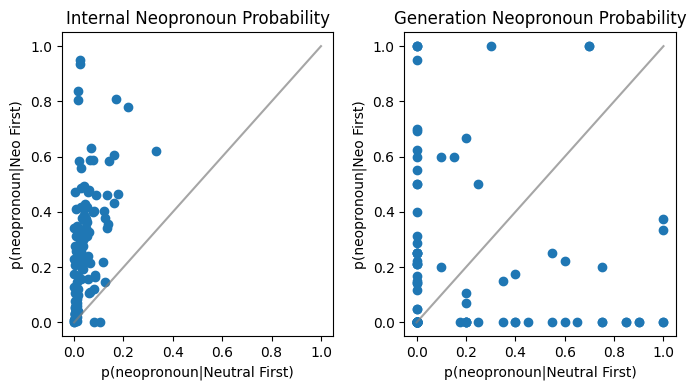

In [21]:
all_tfirst_int = []
all_xfirst_int = []

all_tfirst_gen = []
all_xfirst_gen = []

for direction in llama_neutral_biases_single.values():
    all_tfirst_int.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['internal']['mfirst']])
    all_xfirst_int.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['internal']['ffirst']])
    all_tfirst_gen.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['generation']['mfirst']])
    all_xfirst_gen.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['generation']['ffirst']])

fig, axs = plt.subplots(1, 2, figsize=(7, 4)) 

axs[0].scatter(all_tfirst_int, all_xfirst_int)
axs[1].scatter(all_tfirst_gen, all_xfirst_gen)

axs[0].set_title('Internal Neopronoun Probability')
axs[0].set_xlabel('p(neopronoun|Neutral First)')
axs[0].set_ylabel('p(neopronoun|Neo First)')

axs[1].set_title('Generation Neopronoun Probability')
axs[1].set_xlabel('p(neopronoun|Neutral First)')
axs[1].set_ylabel('p(neopronoun|Neo First)')

axs[0].plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.7)
axs[1].plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.7)

plt.tight_layout()

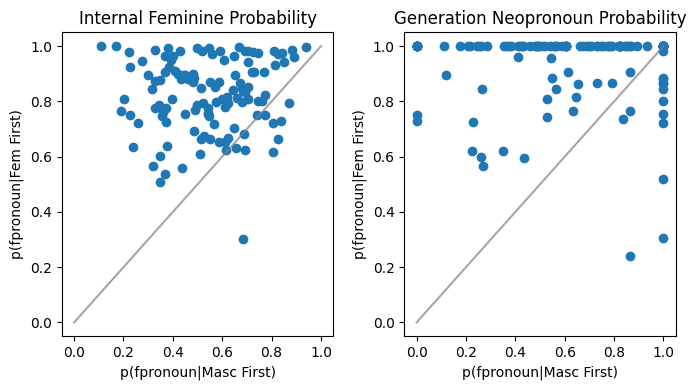

In [22]:
all_mfirst_int = []
all_ffirst_int = []

all_mfirst_gen = []
all_ffirst_gen = []

for direction in llama_gendered_biases_single.values():
    all_mfirst_int.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['internal']['mfirst']])
    all_ffirst_int.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['internal']['ffirst']])
    all_mfirst_gen.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['generation']['mfirst']])
    all_ffirst_gen.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['generation']['ffirst']])

fig, axs = plt.subplots(1, 2, figsize=(7, 4)) 

axs[0].scatter(all_mfirst_int, all_ffirst_int)
axs[1].scatter(all_mfirst_gen, all_ffirst_gen)

axs[0].set_title('Internal Feminine Probability')
axs[0].set_xlabel('p(fpronoun|Masc First)')
axs[0].set_ylabel('p(fpronoun|Fem First)')

axs[1].set_title('Generation Neopronoun Probability')
axs[1].set_xlabel('p(fpronoun|Masc First)')
axs[1].set_ylabel('p(fpronoun|Fem First)')

axs[0].plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.7)
axs[1].plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.7)

plt.tight_layout()

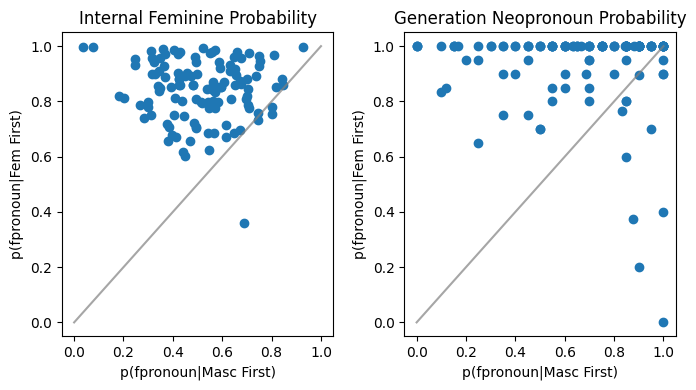

In [23]:
all_mfirst_int = []
all_ffirst_int = []

all_mfirst_gen = []
all_ffirst_gen = []

for direction in llama_prompted_biases_single.values():
    all_mfirst_int.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['internal']['mfirst']])
    all_ffirst_int.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['internal']['ffirst']])
    all_mfirst_gen.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['generation']['mfirst']])
    all_ffirst_gen.extend([x[1] if ~np.any(np.isnan(x)) else 0 for x in direction['generation']['ffirst']])

fig, axs = plt.subplots(1, 2, figsize=(7, 4)) 

axs[0].scatter(all_mfirst_int, all_ffirst_int)
axs[1].scatter(all_mfirst_gen, all_ffirst_gen)

axs[0].set_title('Internal Feminine Probability')
axs[0].set_xlabel('p(fpronoun|Masc First)')
axs[0].set_ylabel('p(fpronoun|Fem First)')

axs[1].set_title('Generation Neopronoun Probability')
axs[1].set_xlabel('p(fpronoun|Masc First)')
axs[1].set_ylabel('p(fpronoun|Fem First)')

axs[0].plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.7)
axs[1].plot(np.linspace(0,1,20), np.linspace(0,1,20), color='gray', alpha=0.7)

plt.tight_layout()

Text(0.5, 1.0, '$\\langle p(fpro | mfirst) - p(fpro | ffirst) \\rangle$, Llama 3.2 1B')

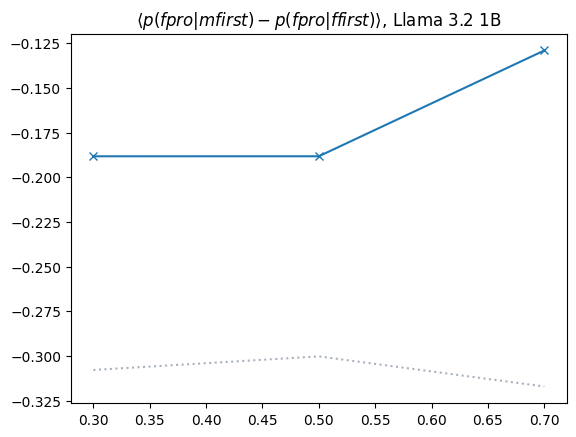

In [24]:
llama03_bias = order_bias(llama32_03)
llama05_bias = order_bias(llama32)
llama07_bias = order_bias(llama32_07)

internal_diffs = [
    mean_order_difference(llama03_bias, single_only=True, mode='internal'),
    mean_order_difference(llama05_bias, single_only=True, mode='internal'),
    mean_order_difference(llama07_bias, single_only=True, mode='internal')
]

generation_diffs = [
    mean_order_difference(llama03_bias, single_only=True, mode='generation'),
    mean_order_difference(llama05_bias, single_only=True, mode='generation'),
    mean_order_difference(llama07_bias, single_only=True, mode='generation')
]

temps = [0.3, 0.5, 0.7]

plt.plot(temps, internal_diffs, color='slategrey', alpha=0.6, linestyle='dotted')
plt.plot(temps, generation_diffs,  marker='x')
#plt.ylim(-1, 1)

plt.title(r"$\langle p(fpro | mfirst) - p(fpro | ffirst) \rangle$, Llama 3.2 1B") 

### Order Difference (not Mean)

In [25]:
def plot_order_bias(bias_dict: dict,
                   mode: str,
                   title: str = "Order Biases",
                   max_index: int = 60):
    
    mfirst_probs = []
    ffirst_probs = []
    
    for idx in range(max_llama):
        mfirst_probs.extend([direction["internal"]["mfirst"][idx][1] for direction in llama_order_bias.values()])
        ffirst_probs.extend([direction["internal"]["ffirst"][idx][1] for direction in llama_order_bias.values()])
    
    for n,pair in enumerate(zip(mfirst_probs, ffirst_probs)):
        plt.vlines(x=n, ymin=np.min(pair), ymax=np.max(pair), color='gray', alpha=0.6, linewidth=0.7)
    plt.plot(range(len(mfirst_probs)), mfirst_probs, linestyle="None", marker="x", markersize=5)
    plt.plot(range(len(ffirst_probs)), ffirst_probs, linestyle="None", marker="o", markersize=5)
    plt.title("Order Biases in Llama 3.2 1B")

In [26]:
def plot_order_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        unprimed_1 = prob_func(get_sent_order([0, 1], get_single_sentences(all_index_data)))
        unprimed_2 = prob_func(get_sent_order([1, 0], get_single_sentences(all_index_data)))
        

        tup1 = (unprimed_1, primed_m1, primed_f1)
        tup2 = (unprimed_2, primed_m2, primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    return differences

### Primed Completion Differences

In [27]:
def is_valid_tuple(tup):
        return not any(np.isnan(arr).any() for arr in tup)

In [28]:
def primed_completion_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60,
                                  plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        unprimed_1 = prob_func(get_sent_order([0, 1], get_single_sentences(all_index_data)))
        unprimed_2 = prob_func(get_sent_order([1, 0], get_single_sentences(all_index_data)))

        primed_m1 = prob_func(get_sent_order([0, 1], get_filled_pnoun(0, all_index_data)))
        primed_f1 = prob_func(get_sent_order([0, 1], get_filled_pnoun(1, all_index_data)))
        primed_m2 = prob_func(get_sent_order([1, 0], get_filled_pnoun(0, all_index_data)))
        primed_f2 = prob_func(get_sent_order([1, 0], get_filled_pnoun(1, all_index_data)))

        tup1 = (unprimed_1, primed_m1, primed_f1)
        tup2 = (unprimed_2, primed_m2, primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    return differences

  0%|          | 0/60 [00:00<?, ?it/s]

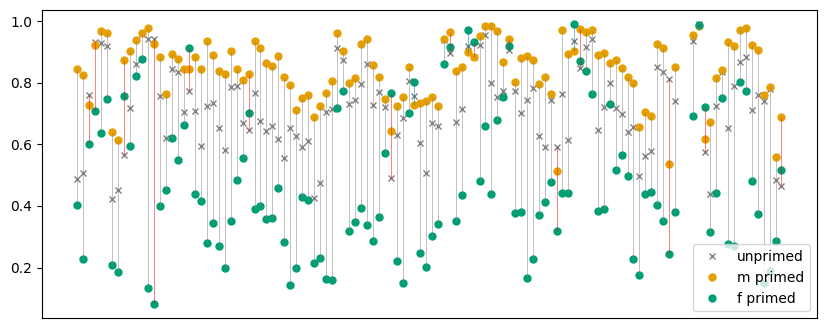

In [29]:
int_llama_neutral_prim_diffs = primed_completion_differences(llama32, 'internal', plot=True)

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 16:57:56.925 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 16:57:56.927 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


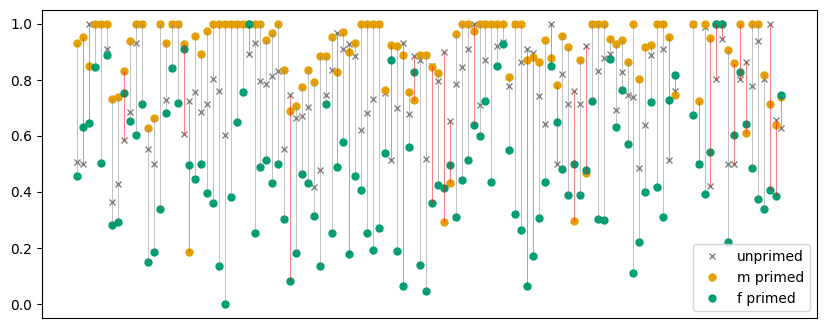

In [30]:
gen_llama_neutral_prim_diffs = primed_completion_differences(llama32, 'generation', plot=True)

### Mean Shifts

In [31]:
def mean_completion_shift(data: list[Measurement] | list[tuple],
                          mode: str | None = None,
                          max_index: int = 60):

    """
    Calculates the mean shift (across all ordered sentences pairs) in the probability of female pronoun production for
    mprimed and fprimed sentences. 

    :param data: list of Measurement objects (or equivalently structured dictionaries) OR 
         list of tuples from primed_completion_differences()
    :param mode: 'internal' or 'generation' (only necessary if data is a list of dicts/Measurements)
    :param max_index: maximum index in data (last index is thrown away)

    :returns: (mean shift mprimed, mean shift fprimed, array of shifts with mprimed, array of shifts with fprimed)
    
    """

    if isinstance(data[0], dict) or isinstance(data[0], Measurement):
        if mode is None:
            raise AttributeError("Must define mode if data is not a list of probability tupes")
        else:
            tuples = primed_completion_differences(data, mode, max_index, plot=False)
    else:
        tuples = data

    pruned_tuples = [t for t in tuples if is_valid_tuple(t)]

    unprimed_fprobs = np.array([t[0][1] for t in pruned_tuples])
    mprimed_fprobs = np.array([t[1][1] for t in pruned_tuples])
    fprimed_fprobs = np.array([t[2][1] for t in pruned_tuples])

    mshift = mprimed_fprobs - unprimed_fprobs
    fshift = fprimed_fprobs - unprimed_fprobs

    mean_mshift = np.nanmean(mshift)
    mean_fshift = np.nanmean(fshift)
    
    return mean_mshift, mean_fshift, mshift, fshift

In [32]:
int_llama32_shifts = mean_completion_shift(int_llama_neutral_prim_diffs)
gen_llama32_shifts = mean_completion_shift(gen_llama_neutral_prim_diffs)

In [33]:
int_llama32_shifts[:2], gen_llama32_shifts[:2]

((np.float64(0.11491992491839796), np.float64(-0.25158174506231973)),
 (np.float64(0.10554982805480874), np.float64(-0.29499788503676216)))

In [34]:
int_llama32_07_shifts = mean_completion_shift(llama32_07, mode='internal')
gen_llama32_07_shifts = mean_completion_shift(llama32_07, mode='generation')

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 16:58:01.837 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


In [35]:
int_llama32_03_shifts = mean_completion_shift(llama32_03, mode='internal')
gen_llama32_03_shifts = mean_completion_shift(llama32_03, mode='generation')

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 16:58:06.112 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 16:58:06.112 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 16:58:06.113 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 16:58:06.113 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 16:58:06.185 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


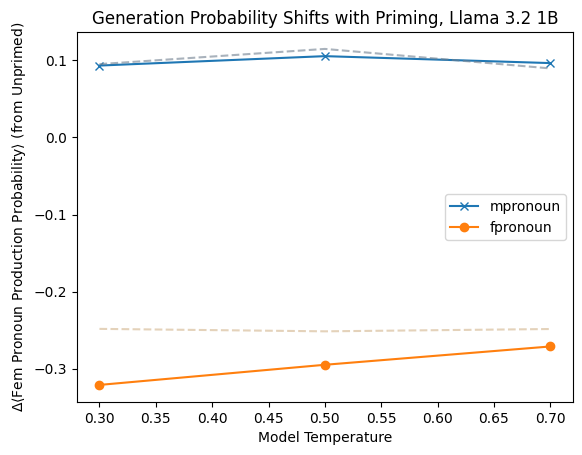

In [36]:
plt.plot([0.3, 0.5, 0.7],
         [gen_llama32_03_shifts[0], gen_llama32_shifts[0], gen_llama32_07_shifts[0]], label='mpronoun', marker='x')
plt.plot([0.3, 0.5, 0.7],
         [gen_llama32_03_shifts[1], gen_llama32_shifts[1], gen_llama32_07_shifts[1]], label='fpronoun', marker='o')

plt.plot([0.3, 0.5, 0.7],
         [int_llama32_03_shifts[0], int_llama32_shifts[0], int_llama32_07_shifts[0]],  linestyle='dashed', alpha=0.6,
        color='slategrey')
plt.plot([0.3, 0.5, 0.7],
         [int_llama32_03_shifts[1], int_llama32_shifts[1], int_llama32_07_shifts[1]],  linestyle='dashed', alpha=0.6,
        color='tan')

plt.ylabel(r"$\Delta \langle$Fem Pronoun Production Probability$\rangle$ (from Unprimed)")
plt.xlabel("Model Temperature")
plt.title("Generation Probability Shifts with Priming, Llama 3.2 1B")
plt.legend()

### Does it Depend on Occupation?

In [37]:
# ref_role, other_role
# {index: {forward: (ref_role, other_role), reverse: (ref_role, other_role)}}

pnoun_role_dict = defaultdict(dict)
for idx in range(max_llama):

    forward_sentence_idx = int((2 * idx) + 1)
    reverse_sentence_idx = int(2 * idx)

    answer_mapping = {0: 'occupation(0)', 1: 'other-participant(1)'}

    forward_ref_col = answer_mapping[templates['answer'][forward_sentence_idx]]
    forward_other_col = answer_mapping[(templates['answer'][forward_sentence_idx] + 1) % 2]
    reverse_ref_col = answer_mapping[templates['answer'][reverse_sentence_idx]]
    reverse_other_col = answer_mapping[(templates['answer'][reverse_sentence_idx] + 1) % 2]

    pnoun_role_dict[idx]['forward'] = (templates[forward_ref_col][forward_sentence_idx], templates[forward_other_col][forward_sentence_idx])
    pnoun_role_dict[idx]['reverse'] = (templates[reverse_ref_col][reverse_sentence_idx], templates[reverse_other_col][reverse_sentence_idx])

$$\operatorname{logit} P(X=1)=β_0 + β_O \cdot O + β_{P1} \cdot \mathbf{1}_{[Pr=m]}+β_{P2} \cdot \mathbf{1}_{[Pr=f]}$$

In [38]:
# Creating a df for the first index, only generation
# X, O, P

# THIS IS INCORRECT - THIS IS COMBINING BOTH.. SHOULD BE TWO SEPERATE.. or should it.. given the roles as a variable..

test_list_fwd = get_sent_order([0,1],get_index(0,llama32))
test_list_bwd = get_sent_order([1,0],get_index(0,llama32))
#test_list_fwd

forward_occ = pnoun_role_dict.get(0)['forward'][0]
reverse_occ = pnoun_role_dict.get(0)['reverse'][0]

forward_prime_list = [str(m['context']['pnoun_order'][0]) for m in test_list_fwd]
backward_prime_list = [str(m['context']['pnoun_order'][0]) for m in test_list_bwd]

fwd_measurement_list = [m['measurement']['BLANK'] for m in test_list_fwd if m['measurement']['BLANK'] is not None]
bwd_measurement_list = [m['measurement']['BLANK'] for m in test_list_bwd if m['measurement']['BLANK'] is not None]

fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in test_list_fwd]
bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in test_list_bwd]

llama_measurements_df = pd.DataFrame(data={
    'Measurement': fwd_measurement_list + bwd_measurement_list, 
    'Role': [forward_occ] * len(test_list_fwd) + [reverse_occ]*len(test_list_bwd),
    'GPrime': forward_prime_list + backward_prime_list,
    'POrder': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
})

llama_measurements_df["X"] = (llama_measurements_df["Measurement"] == "she").astype(int)

In [39]:
def create_regression_table(index: int, 
                            data: list[Measurement] | list[dict]):

    """
    Creates a DataFrame with columns [Measurement, Role, GPrime, POrder] for a *pair of sentences* using measurements provided. 

    :param data: List of Measurements (or equivalent dictionaries) 

    """

    fwd_list = get_sent_order([0,1],get_index(index,data, filter_none=True))
    bwd_list = get_sent_order([1,0],get_index(index,data, filter_none=True))

    forward_occ = pnoun_role_dict.get(index)['forward'][0]
    reverse_occ = pnoun_role_dict.get(index)['reverse'][0]

    fwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in fwd_list]
    bwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in bwd_list]

    fwd_measurement_list = [m['measurement']['BLANK'] for m in fwd_list if m['measurement']['BLANK'] is not None]
    bwd_measurement_list = [m['measurement']['BLANK'] for m in bwd_list if m['measurement']['BLANK'] is not None]

    fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in fwd_list]
    bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in bwd_list]

    measurements_df = pd.DataFrame(data={
    'Measurement': fwd_measurement_list + bwd_measurement_list, 
    'Role': [forward_occ] * len(fwd_list) + [reverse_occ]*len(bwd_list),
    'GPrime': fwd_prime_list + bwd_prime_list,
    'POrder': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
    })

    measurements_df["X"] = (measurements_df["Measurement"] == "she").astype(int)

    return measurements_df
    
    

In [40]:
def or_table(model):
    ci = model.conf_int()
    or_df = pd.DataFrame({
        "OR": np.exp(model.params),
        "CI_low": np.exp(ci[0]),
        "CI_high": np.exp(ci[1]),
        "p": model.pvalues
    })
    return or_df

In [41]:
def lrt(m_reduced, m_full):
    LR = 2 * (m_full.llf - m_reduced.llf)
    df = m_full.df_model - m_reduced.df_model
    p = stats.chi2.sf(LR, df)
    return {"LR": LR, "df": df, "p": p}

In [42]:
def metrics(model, data):
    p = model.predict(data)
    return {
        "log_loss": log_loss(data["X"], p, labels=[0, 1]),
        "AUC": roc_auc_score(data["X"], p)
    }

#### With Order

In [43]:
# THIS IS ONLY FOR A SINGLE INDEX

In [82]:
def _safe_exp(x, clip=30.0):
    if pd.isna(x): 
        return np.nan
    return float(np.exp(np.clip(x, -clip, clip)))

def _get_or_ci_by_name(model, name_substr):
    """
    Find the FIRST parameter whose name contains `name_substr`,
    return OR, p, OR_lo, OR_hi (exp of coef & CI), safely clipped.
    If not found, returns (np.nan, np.nan, np.nan, np.nan).
    """
    params = model.params
    conf   = model.conf_int()
    pvals  = model.pvalues
    # find first match
    for nm in params.index:
        if name_substr in str(nm):
            beta = float(params.loc[nm])
            lo, hi = conf.loc[nm]
            return (_safe_exp(beta),
                    float(pvals.loc[nm]),
                    _safe_exp(lo),
                    _safe_exp(hi))
    return (np.nan, np.nan, np.nan, np.nan)

def shift_summary_table(order: bool,
                        data: list,
                        max_index: int = 60):
    """
    Per-pair GLM(Binomial) ablation summary with robust OR extraction.
    """

    out_df = defaultdict(list)

    for index in tqdm(range(max_index)):
        df = create_regression_table(index, data)

        try:
            # Fit GLM Binomial (more stable than Logit)
            if order:
                formula_main = "X ~ Role + C(GPrime, Treatment('None')) + C(POrder)"
                m_noO = smf.glm("X ~ C(GPrime, Treatment('None')) + C(POrder)",
                                data=df, family=sm.families.Binomial()).fit(disp=0)
                m_noP = smf.glm("X ~ Role + POrder",
                                data=df, family=sm.families.Binomial()).fit(disp=0)
                m_noPn = smf.glm("X ~ Role + C(GPrime, Treatment('None'))",
                                 data=df, family=sm.families.Binomial()).fit(disp=0)
            else:
                formula_main = "X ~ Role + C(GPrime, Treatment('None'))"
                m_noO = smf.glm("X ~ C(GPrime, Treatment('None'))",
                                data=df, family=sm.families.Binomial()).fit(disp=0)
                m_noP = smf.glm("X ~ Role",
                                data=df, family=sm.families.Binomial()).fit(disp=0)

            m_full = smf.glm(formula_main, data=df, family=sm.families.Binomial()).fit(disp=0)

            # ---- ORs by NAME (robust to dropped terms) ----
            # Intercept
            OR_int, p_int, OR_int_lo, OR_int_hi = _get_or_ci_by_name(m_full, "Intercept")
            # Role: grab whichever Role dummy Patsy created
            OR_role, p_role, OR_role_lo, OR_role_hi = _get_or_ci_by_name(m_full, "Role")
            # Priming he/she
            OR_m, p_m, OR_m_lo, OR_m_hi   = _get_or_ci_by_name(m_full, "C(GPrime, Treatment('None'))[T.he]")
            OR_f, p_f, OR_f_lo, OR_f_hi   = _get_or_ci_by_name(m_full, "C(GPrime, Treatment('None'))[T.she]")
            # Order: numeric POrder or categorical C(POrder)[T.*]
            found_order = False
            OR_ord = p_ord = OR_ord_lo = OR_ord_hi = np.nan
            if order:
                if "POrder" in m_full.params.index:
                    OR_ord, p_ord, OR_ord_lo, OR_ord_hi = _get_or_ci_by_name(m_full, "POrder")
                    found_order = True
                else:
                    # try categorical dummies
                    OR_ord, p_ord, OR_ord_lo, OR_ord_hi = _get_or_ci_by_name(m_full, "C(POrder)[T.")
                    found_order = np.isfinite(OR_ord)

        except Exception as e:
            logger.error(f"Error running regression for index {index}: {e}")
            continue

        # ---- Likelihood Ratios ----
        lrt_O = lrt(m_noO, m_full)
        lrt_P = lrt(m_noP, m_full)
        if order:
            lrt_Pn = lrt(m_noPn, m_full)

        # ---- Metrics (AUC may warn if only one class; that's OK) ----
        metrics_full = metrics(m_full, df)
        metrics_noO  = metrics(m_noO,  df)
        metrics_noP  = metrics(m_noP,  df)
        if order:
            metrics_noPn = metrics(m_noPn, df)

        # ---- Collect outputs ----
        out_df['index'].append(index)

        out_df['or_intercept'].append(OR_int)
        out_df['or_intercept_p'].append(p_int)

        out_df['or_role'].append(OR_role)
        out_df['or_role_p'].append(p_role)

        out_df['or_mpronoun'].append(OR_m)
        out_df['or_mpronoun_p'].append(p_m)

        out_df['or_fpronoun'].append(OR_f)
        out_df['or_fpronoun_p'].append(p_f)

        if order and found_order:
            out_df['or_order'].append(OR_ord)
            out_df['or_order_p'].append(p_ord)

        out_df['or_role_lo'].append(OR_role_lo)
        out_df['or_role_hi'].append(OR_role_hi)
        
        out_df['or_mpronoun_lo'].append(OR_m_lo)
        out_df['or_mpronoun_hi'].append(OR_m_hi)
        
        out_df['or_fpronoun_lo'].append(OR_f_lo)
        out_df['or_fpronoun_hi'].append(OR_f_hi)
        
        if order and found_order:
            out_df['or_order_lo'].append(OR_ord_lo)
            out_df['or_order_hi'].append(OR_ord_hi)


        out_df['lrt_role'].append(lrt_O['LR'])
        out_df['lrt_role_p'].append(lrt_O['p'])
        out_df['lrt_pronoun'].append(lrt_P['LR'])
        out_df['lrt_pronoun_p'].append(lrt_P['p'])
        if order:
            out_df['lrt_order'].append(lrt_Pn['LR'])
            out_df['lrt_order_p'].append(lrt_Pn['p'])

        out_df['log_loss_full'].append(metrics_full['log_loss'])
        out_df['AUC_full'].append(metrics_full['AUC'])
        out_df['log_loss_role'].append(metrics_noO['log_loss'])
        out_df['AUC_role'].append(metrics_noO['AUC'])
        out_df['log_loss_pronoun'].append(metrics_noP['log_loss'])
        out_df['AUC_pronoun'].append(metrics_noP['AUC'])
        if order:
            out_df['log_loss_order'].append(metrics_noPn['log_loss'])
            out_df['AUC_order'].append(metrics_noPn['AUC'])

    df_out = pd.DataFrame(out_df).set_index('index')
    return df_out

In [83]:
test_summary_2 = shift_summary_table(order=True,data=llama32)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnin

In [84]:
test_summary_2.columns

Index(['or_intercept', 'or_intercept_p', 'or_role', 'or_role_p', 'or_mpronoun',
       'or_mpronoun_p', 'or_fpronoun', 'or_fpronoun_p', 'or_order',
       'or_order_p', 'or_role_lo', 'or_role_hi', 'or_mpronoun_lo',
       'or_mpronoun_hi', 'or_fpronoun_lo', 'or_fpronoun_hi', 'or_order_lo',
       'or_order_hi', 'lrt_role', 'lrt_role_p', 'lrt_pronoun', 'lrt_pronoun_p',
       'lrt_order', 'lrt_order_p', 'log_loss_full', 'AUC_full',
       'log_loss_role', 'AUC_role', 'log_loss_pronoun', 'AUC_pronoun',
       'log_loss_order', 'AUC_order'],
      dtype='object')

In [85]:
def get_or_heatmap(table: pd.DataFrame, title: str = "Log-Odds Differences"):
    """
    Heatmap of log-odds differences vs Role:
        log OR(col) - log OR(Role)
    Gracefully handles missing columns (e.g., no 'or_order') and zeros/NaNs.
    """

    # We must have a baseline to compare against
    if "or_role" not in table.columns:
        raise ValueError("Expected 'or_role' in table columns.")

    # Map display labels -> column names you might have
    candidates = OrderedDict([
        ("Masc Priming Pronoun", "or_mpronoun"),
        ("Fem Priming Pronoun",  "or_fpronoun"),
        ("Order",                "or_order"),
    ])

    # Keep only columns that actually exist
    cols_present = {lab: col for lab, col in candidates.items() if col in table.columns}
    if not cols_present:
        raise ValueError("None of the comparison OR columns are present in the table.")

    # Safe log transform (skip zeros/negatives)
    role_log = np.log(table["or_role"].where(table["or_role"] > 0))
    delta_log_or = pd.DataFrame(index=table.index)

    for label, col in cols_present.items():
        x_log = np.log(table[col].where(table[col] > 0))
        delta_log_or[label] = x_log - role_log  # will be NaN if either side is NaN

    # Drop rows where all diffs are NaN (skip pairs with unusable data)
    delta_log_or = delta_log_or.loc[~delta_log_or.isna().all(axis=1)]

    # Nothing to plot?
    if delta_log_or.empty:
        print("No valid rows to plot after filtering.")
        return None

    # Symmetric color scale around zero
    vmax = np.nanmax(np.abs(delta_log_or.values))
    vmin = -vmax

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(delta_log_or.values, aspect="auto", interpolation="nearest",
                   cmap="RdBu_r", vmin=vmin, vmax=vmax)

    ax.set_title(title)
    ax.set_xticks(range(delta_log_or.shape[1]))
    ax.set_xticklabels(delta_log_or.columns, rotation=45, ha="right")

    ax.set_yticks(range(delta_log_or.shape[0]))
    ax.set_yticklabels(delta_log_or.index, fontsize=6)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log OR(\cdot)\;-\;\log OR(\text{Role})$")

    plt.tight_layout()
    plt.show()
    return fig


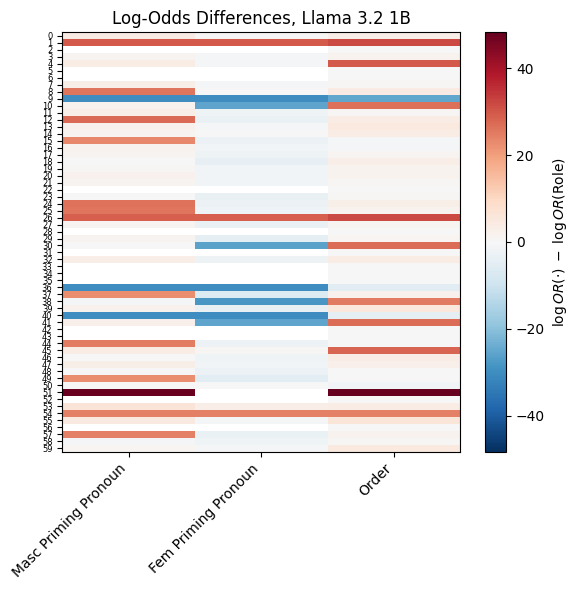

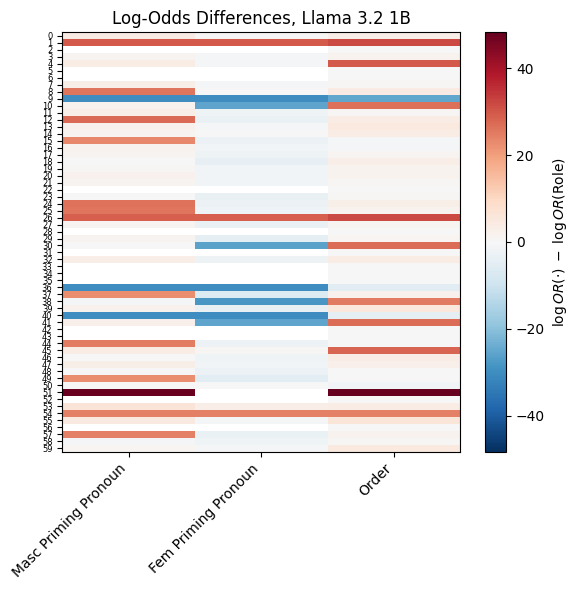

In [86]:
get_or_heatmap(test_summary_2, title="Log-Odds Differences, Llama 3.2 1B")

In [87]:
# AUC Heatmap

def get_auc_heatmap(table: pd.DataFrame,
                   title: str = "Ablation Study"):

    auc_cols = ["AUC_role", "AUC_full", "AUC_pronoun", "AUC_order"]
    auc = table[auc_cols]

    delta_auc = pd.DataFrame({
    "Full − Role": auc["AUC_full"] - auc["AUC_role"],
    "Full − Pronoun": auc["AUC_full"] - auc["AUC_pronoun"],
    "Full − Order": auc["AUC_full"] - auc["AUC_order"]
    })

    fig2, ax2 = plt.subplots(figsize=(6,6))
    im2 = ax2.imshow(delta_auc, aspect="auto", interpolation="nearest", cmap="Purples")
    ax2.set_title(title)
    ax2.set_xticks(range(delta_auc.shape[1]))
    ax2.set_xticklabels(delta_auc.columns, rotation=45, ha="right")
    ax2.set_yticks(range(len(table)))
    ax2.set_yticklabels(table.index, fontsize=6)

    cbar2 = fig2.colorbar(im2, ax=ax2)
    cbar2.set_label("AUC Difference")
    plt.tight_layout()
    plt.show()

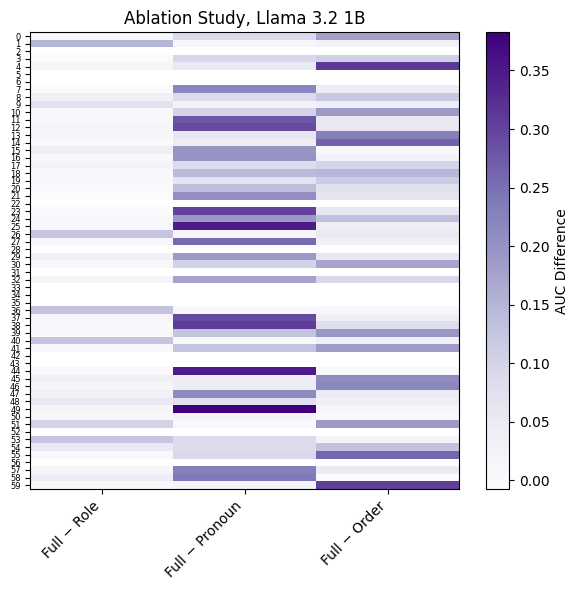

In [88]:
get_auc_heatmap(test_summary_2, "Ablation Study, Llama 3.2 1B")

#### Analysis Without Order

In [51]:
formula_main_no = "X ~ Role + C(GPrime, Treatment('None'))"

In [52]:
m_full_no = smf.logit(formula_main_no, data=llama_measurements_df).fit(disp=False)

In [53]:
# Odds Ratio
or_main_no = or_table(m_full_no)
or_main_no

,OR,CI_low,CI_high,p
Intercept,1.103728,0.920681,1.323168,2.860932e-01
Role[T.technician],0.845917,0.669802,1.068338,1.600363e-01
"C(GPrime, Treatment('None'))[T.he]",16.572213,10.097346,27.199053,1.159157e-28
"C(GPrime, Treatment('None'))[T.she]",1.256051,0.954584,1.652725,1.035173e-01


In [54]:
# Ablated Logit Models
m_noO_no = smf.logit("X ~ C(GPrime, Treatment('None'))", data=llama_measurements_df).fit(disp=False)
m_noP_no = smf.logit("X ~ Role", data=llama_measurements_df).fit(disp=False)

In [55]:
# Likelihood Ratios
lrt_O_no = lrt(m_noO_no, m_full_no) 
lrt_P_no = lrt(m_noP_no, m_full_no)  
lrt_O_no, lrt_P_no

({'LR': np.float64(1.9739581115795772),
  'df': 1.0,
  'p': np.float64(0.16002835677702423)},
 {'LR': np.float64(234.0937271337275),
  'df': 2.0,
  'p': np.float64(1.4695793095205707e-51)})

In [56]:
# ML Metrics
metrics_full_no = metrics(m_full_no, llama_measurements_df)
metrics_noO_no  = metrics(m_noO_no,  llama_measurements_df)  
metrics_noP_no  = metrics(m_noP_no,  llama_measurements_df) 

## Qwen 1.5

### Primed Completion Differences

## Phi 4

## GPT 

### First Pronoun Bias

Text(0.5, 1.0, '$\\langle p(fpro | mfirst) - p(fpro | ffirst) \\rangle$, GPT OSS 20B')

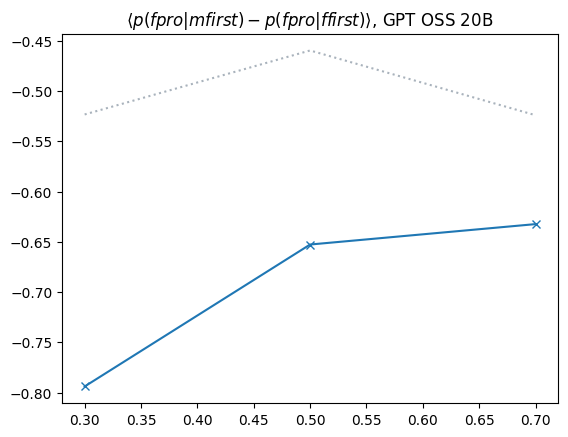

In [57]:
internal_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='internal'),
    mean_order_difference(gpt, single_only=True, mode='internal'),
    mean_order_difference(gpt_07, single_only=True, mode='internal')
]

generation_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='generation'),
    mean_order_difference(gpt, single_only=True, mode='generation'),
    mean_order_difference(gpt_07, single_only=True, mode='generation')
]

temps = [0.3, 0.5, 0.7]

plt.plot(temps, internal_diffs, color='slategrey', alpha=0.6, linestyle='dotted')
plt.plot(temps, generation_diffs,  marker='x')

plt.title(r"$\langle p(fpro | mfirst) - p(fpro | ffirst) \rangle$, GPT OSS 20B") 

### Primed Completion Differences

  0%|          | 0/60 [00:00<?, ?it/s]

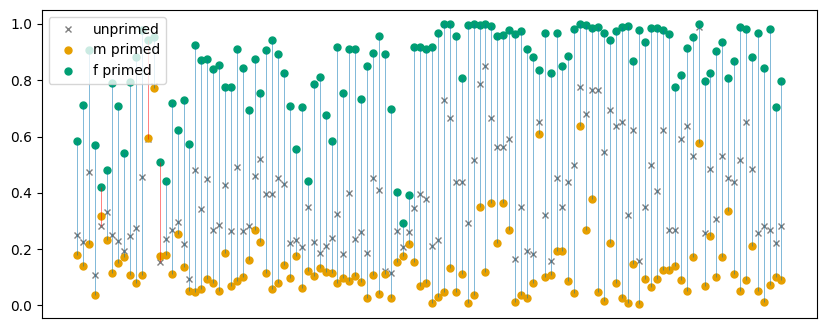

In [58]:
int_gpt_neutral_prim_diffs = primed_completion_differences(gpt, 'internal', plot=True)

  0%|          | 0/60 [00:00<?, ?it/s]

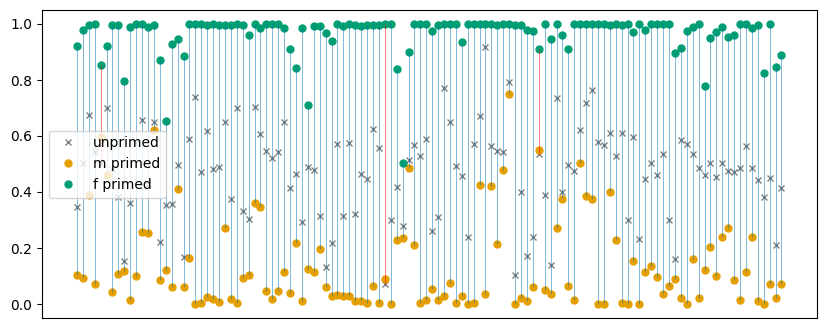

In [59]:
gen_gpt_neutral_prim_diffs = primed_completion_differences(gpt, 'generation', plot=True)

### Mean Shifts

In [60]:
int_gpt_shifts = mean_completion_shift(int_gpt_neutral_prim_diffs)
gen_gpt_shifts = mean_completion_shift(gen_gpt_neutral_prim_diffs)

In [61]:
int_gpt_07_shifts = mean_completion_shift(gpt_07, mode='internal')
gen_gpt_07_shifts = mean_completion_shift(gpt_07, mode='generation')

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

In [62]:
int_gpt_03_shifts = mean_completion_shift(gpt_03, mode='internal')
gen_gpt_03_shifts = mean_completion_shift(gpt_03, mode='generation')

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

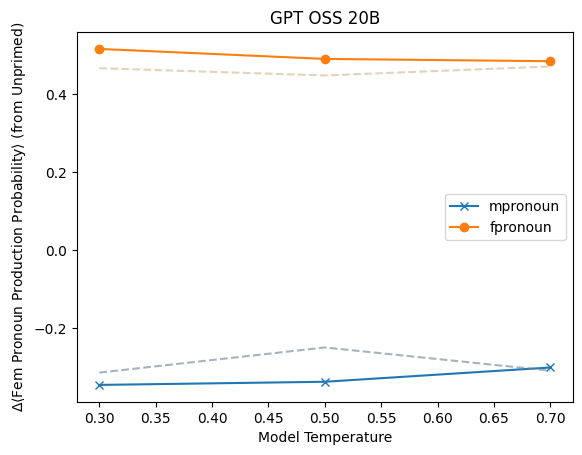

In [63]:
plt.plot([0.3, 0.5, 0.7],
         [gen_gpt_03_shifts[0], gen_gpt_shifts[0], gen_gpt_07_shifts[0]], label='mpronoun', marker='x')
plt.plot([0.3, 0.5, 0.7],
         [gen_gpt_03_shifts[1], gen_gpt_shifts[1], gen_gpt_07_shifts[1]], label='fpronoun', marker='o')

plt.plot([0.3, 0.5, 0.7],
         [int_gpt_03_shifts[0], int_gpt_shifts[0], int_gpt_07_shifts[0]],  linestyle='dashed', alpha=0.6,
        color='slategrey')
plt.plot([0.3, 0.5, 0.7],
         [int_gpt_03_shifts[1], int_gpt_shifts[1], int_gpt_07_shifts[1]],  linestyle='dashed', alpha=0.6,
        color='tan')

plt.ylabel(r"$\Delta \langle$Fem Pronoun Production Probability$\rangle$ (from Unprimed)")
plt.xlabel("Model Temperature")
plt.title("GPT OSS 20B")
plt.legend()

### Does it Depend on Occupation?

In [64]:
gpt_with_order = shift_summary_table(order=True,data=gpt)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnin

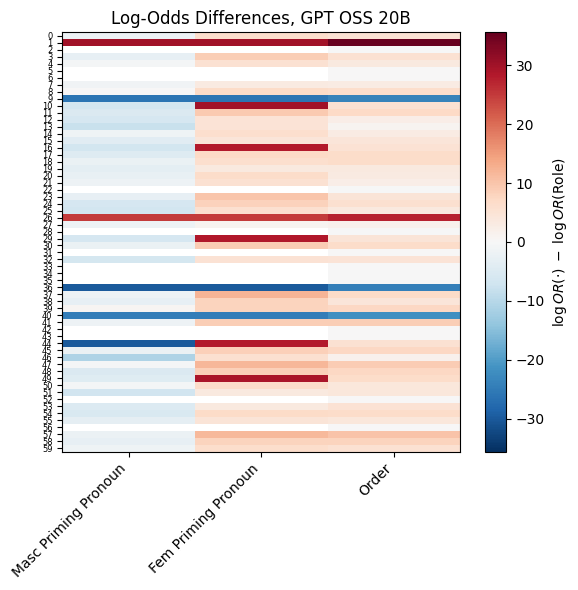

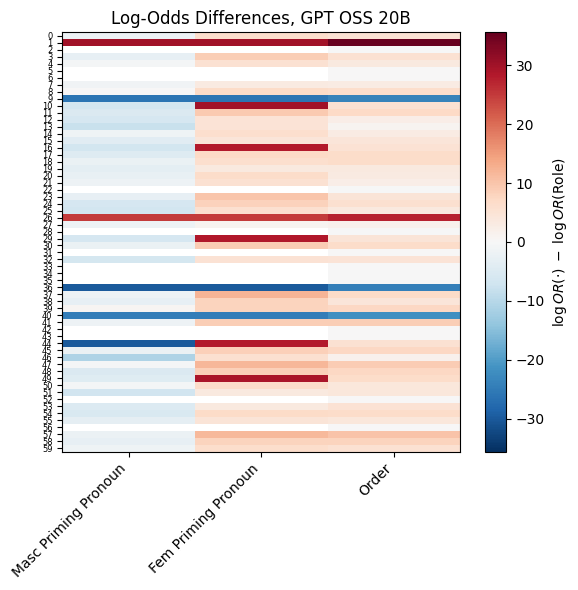

In [65]:
get_or_heatmap(gpt_with_order, title="Log-Odds Differences, GPT OSS 20B")

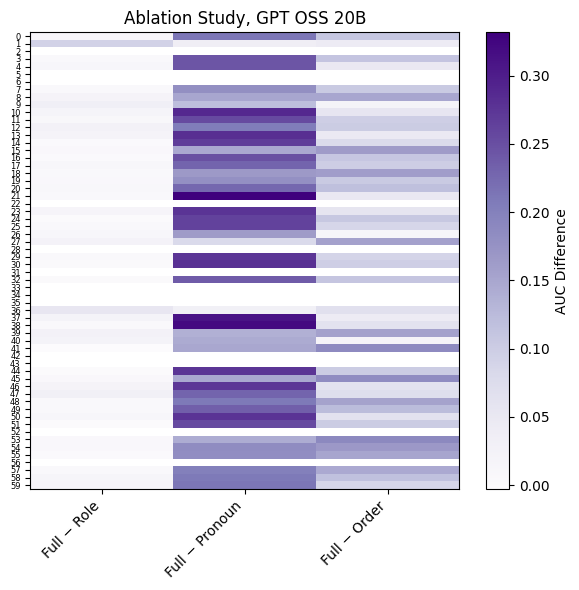

In [66]:
get_auc_heatmap(gpt_with_order, title="Ablation Study, GPT OSS 20B")

## Llama and GPT

/home/sagar/winogender_contextuality/winogender_contextuality/utils.py:241: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values())) / num_valid_measurements


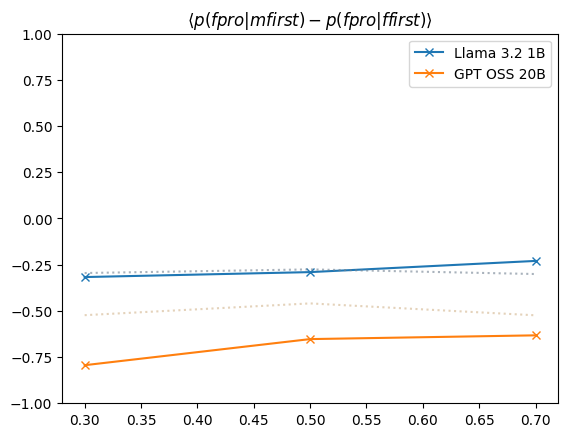

In [67]:
llama_internal_diffs = [
    mean_order_difference(llama32_03, single_only=True, mode='internal'),
    mean_order_difference(llama32, single_only=True, mode='internal'),
    mean_order_difference(llama32_07, single_only=True, mode='internal')
]

llama_generation_diffs = [
    mean_order_difference(llama32_03, single_only=True, mode='generation'),
    mean_order_difference(llama32, single_only=True, mode='generation'),
    mean_order_difference(llama32_07, single_only=True, mode='generation')
]

gpt_internal_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='internal'),
    mean_order_difference(gpt, single_only=True, mode='internal'),
    mean_order_difference(gpt_07, single_only=True, mode='internal')
]

gpt_generation_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='generation'),
    mean_order_difference(gpt, single_only=True, mode='generation'),
    mean_order_difference(gpt_07, single_only=True, mode='generation')
]

temps = [0.3, 0.5, 0.7]

plt.plot(temps, llama_generation_diffs,  marker='x', label='Llama 3.2 1B')
plt.plot(temps, llama_internal_diffs, color='slategrey', alpha=0.6, linestyle='dotted')

plt.plot(temps, gpt_generation_diffs,  marker='x', label='GPT OSS 20B')
plt.plot(temps, gpt_internal_diffs, color='tan', alpha=0.6, linestyle='dotted')

plt.ylim(-1,1)

plt.title(r"$\langle p(fpro | mfirst) - p(fpro | ffirst) \rangle$") 
plt.legend()

# Contextuality

In [68]:
def get_contextuality_table(
    model_measurements: list[dict],
    default_pronoun: int = 1,  # 0 for male, 1 for female
    max_index: int = 60
) -> pd.DataFrame:

    indices = []
    
    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []
    
    for idx in tqdm(range(max_index)):

        try:

            # Internal 
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')
            
            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')
            
            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')

            

        except Exception as e:
            logger.error(f"Error calculating degree of contextuality for index {idx}: {e}")
            continue

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df
        

In [69]:
cont_llama_03 = get_contextuality_table(llama32_03)
cont_llama_05 = get_contextuality_table(llama32)
cont_llama_07 = get_contextuality_table(llama32_07)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


2025-09-19 16:59:31.172 | ERROR    | winogender_contextuality.modeling.contextuality:calculate_sentence_dc_fraction:521 - Error calculating degree of contextuality: list index out of range
2025-09-19 16:59:31.173 | ERROR    | __main__:get_contextuality_table:36 - Error calculating degree of contextuality for index 51: division by zero
2025-09-19 16:59:31.331 | ERROR    | winogender_contextuality.modeling.contextuality:calculate_sentence_dc_fraction:521 - Error calculating degree of contextuality: list index out of range
2025-09-19 16:59:31.332 | ERROR    | __main__:get_contextuality_table:36 - Error calculating degree of contextuality for index 53: division by zero


  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 16:59:37.371 | ERROR    | winogender_contextuality.modeling.contextuality:calculate_sentence_dc_fraction:521 - Error calculating degree of contextuality: list index out of range
2025-09-19 16:59:37.372 | ERROR    | __main__:get_contextuality_table:36 - Error calculating degree of contextuality for index 51: division by zero


  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 16:59:44.027 | ERROR    | winogender_contextuality.modeling.contextuality:calculate_sentence_dc_fraction:521 - Error calculating degree of contextuality: list index out of range
2025-09-19 16:59:44.028 | ERROR    | __main__:get_contextuality_table:36 - Error calculating degree of contextuality for index 51: division by zero


In [70]:
cont_gpt_03 = get_contextuality_table(gpt_03)
cont_gpt_05 = get_contextuality_table(gpt)
cont_gpt_07 = get_contextuality_table(gpt_07)

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

## Degree of Contextuality

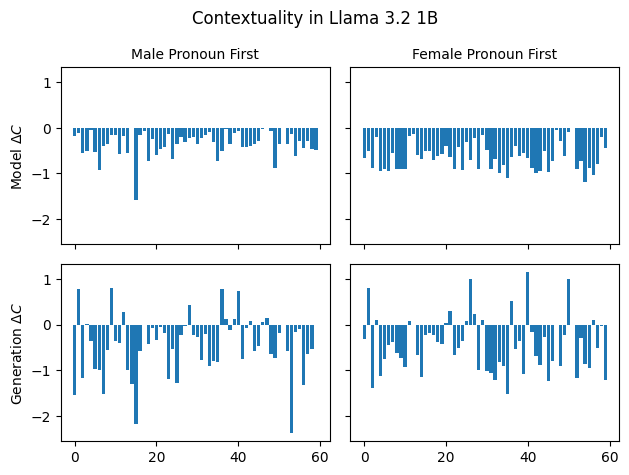

In [71]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(cont_llama_05['index'], cont_llama_05['int_mfirst'])
axs[0,1].bar(cont_llama_05['index'], cont_llama_05['int_ffirst'])
axs[1,0].bar(cont_llama_05['index'], cont_llama_05['gen_mfirst'])
axs[1,1].bar(cont_llama_05['index'], cont_llama_05['gen_ffirst'])


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in Llama 3.2 1B')
plt.tight_layout()

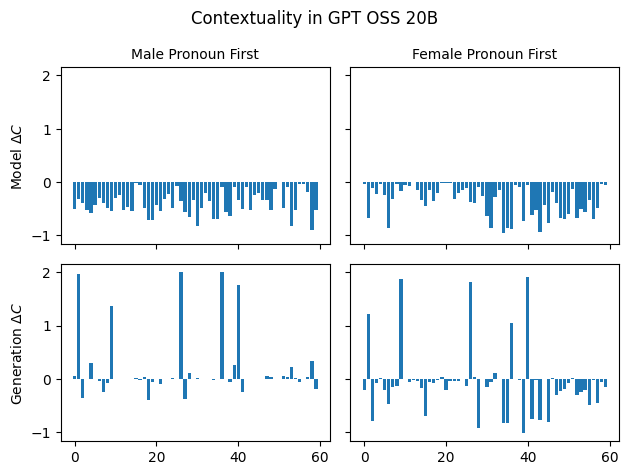

In [72]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(cont_gpt_05['index'], cont_gpt_05['int_mfirst'])
axs[0,1].bar(cont_gpt_05['index'], cont_gpt_05['int_ffirst'])
axs[1,0].bar(cont_gpt_05['index'], cont_gpt_05['gen_mfirst'])
axs[1,1].bar(cont_gpt_05['index'], cont_gpt_05['gen_ffirst'])


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in GPT OSS 20B')
plt.tight_layout()

## Number of contextual pairs 

In [73]:
# Count of Number of Contextual Pairs
(cont_llama_03 > 0).sum(), (cont_llama_05 > 0).sum(), (cont_llama_07 > 0).sum()

(index         57
 int_mfirst     0
 int_ffirst     0
 gen_mfirst    13
 gen_ffirst    14
 dtype: int64,
 index         58
 int_mfirst     0
 int_ffirst     0
 gen_mfirst    13
 gen_ffirst    13
 dtype: int64,
 index         58
 int_mfirst     0
 int_ffirst     0
 gen_mfirst    10
 gen_ffirst    12
 dtype: int64)

In [74]:
(cont_gpt_03 > 0).sum(), (cont_gpt_05 > 0).sum(), (cont_gpt_07 > 0).sum()

(index         59
 int_mfirst     0
 int_ffirst     0
 gen_mfirst    14
 gen_ffirst     7
 dtype: int64,
 index         59
 int_mfirst     0
 int_ffirst     0
 gen_mfirst    25
 gen_ffirst    11
 dtype: int64,
 index         59
 int_mfirst     1
 int_ffirst     0
 gen_mfirst    26
 gen_ffirst    11
 dtype: int64)

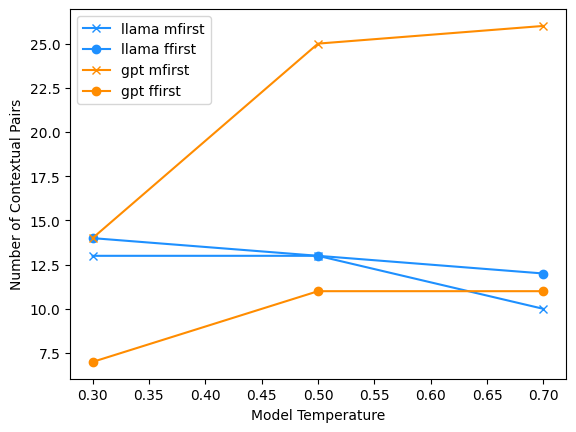

In [75]:
plt.plot(temps,
        [(cont_llama_03 > 0).sum()['gen_mfirst'], (cont_llama_05 > 0).sum()['gen_mfirst'], (cont_llama_07 > 0).sum()['gen_mfirst']],
        marker='x',
        color='dodgerblue',
        label='llama mfirst')
plt.plot(temps,
        [(cont_llama_03 > 0).sum()['gen_ffirst'], (cont_llama_05 > 0).sum()['gen_ffirst'], (cont_llama_07 > 0).sum()['gen_ffirst']],
        marker='o',
        color='dodgerblue',
        label='llama ffirst')

plt.plot(temps,
        [(cont_gpt_03 > 0).sum()['gen_mfirst'], (cont_gpt_05 > 0).sum()['gen_mfirst'], (cont_gpt_07 > 0).sum()['gen_mfirst']],
        marker='x',
        color='darkorange',
        label='gpt mfirst')
plt.plot(temps,
        [(cont_gpt_03 > 0).sum()['gen_ffirst'], (cont_gpt_05 > 0).sum()['gen_ffirst'], (cont_gpt_07 > 0).sum()['gen_ffirst']],
        marker='o',
        color='darkorange',
        label='gpt ffirst')
plt.xlabel("Model Temperature")
plt.ylabel("Number of Contextual Pairs")
plt.legend()

In [94]:
list(range(2))

[0, 1]

# Comparing to Null

## Load Nulls

In [95]:
llama_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Llama-3.2-1B-Instruct_0.5_2113210925.ndjson")

In [124]:
gpt_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_gpt-oss-20b_0.5_2208210925.ndjson")

## Plot Differences

In [115]:
def null_completion_differences(full_data: list[Measurement] | list[dict],
                                null_data: list[Measurement] | list[dict],
                                mode: str,
                                max_index: int = 60,
                                plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, full_data)

        unprimed_1 = prob_func(get_sent_order([0, 1], get_single_sentences(all_index_data)))
        unprimed_2 = prob_func(get_sent_order([1, 0], get_single_sentences(all_index_data)))

        # sentence 2 index = idx + 61
        null_s1 = prob_func(get_index(idx, null_data))
        null_s2 = prob_func(get_index(idx + 61, null_data))

        tup1 = (unprimed_1, null_s1)
        tup2 = (unprimed_2, null_s2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            differences.extend([(np.nan, np.nan), (np.nan, np.nan)])
            print(tup1, tup2)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue
            
            color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    return differences

  0%|          | 0/60 [00:00<?, ?it/s]

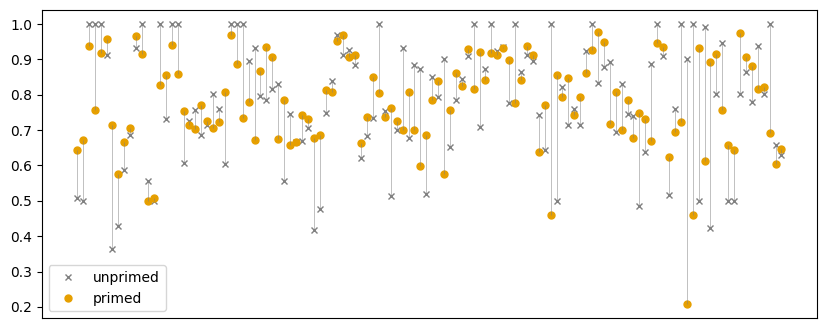

In [117]:
null_llama_diffs = null_completion_differences(llama32, llama_null, "generation", plot=True)

  0%|          | 0/60 [00:00<?, ?it/s]

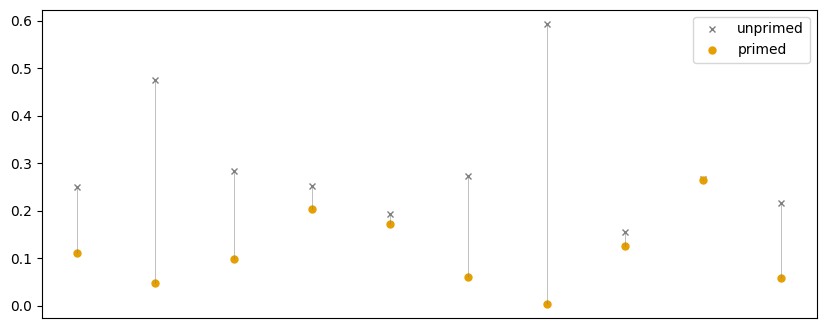

In [125]:
null_gpt_diffs = null_completion_differences(gpt, gpt_null, "internal", plot=True)